<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Epoch   1/100 | LR: 3.16e-04 | train loss 0.9345 acc 0.673 | val loss 0.6232 acc 0.762 *


[DenseNet-121] Epoch   2/100 | LR: 3.16e-04 | train loss 0.7855 acc 0.725 | val loss 0.6931 acc 0.745


[DenseNet-121] Epoch   3/100 | LR: 3.16e-04 | train loss 0.7757 acc 0.715 | val loss 0.6811 acc 0.745


[DenseNet-121] Epoch   4/100 | LR: 3.16e-04 | train loss 0.7536 acc 0.748 | val loss 0.8501 acc 0.698


[DenseNet-121] Epoch   5/100 | LR: 3.16e-04 | train loss 0.6866 acc 0.764 | val loss 0.5564 acc 0.801 *


...

[DenseNet-121] Epoch  22/100 | LR: 3.16e-05 | train loss 0.0962 acc 0.970 | val loss 0.5803 acc 0.827


[DenseNet-121] Epoch  23/100 | LR: 3.16e-05 | train loss 0.0470 acc 0.990 | val loss 0.6346 acc 0.836


[DenseNet-121] Epoch  24/100 | LR: 3.16e-05 | train loss 0.0485 acc 0.988 | val loss 0.6712 acc 0.830


[DenseNet-121] Epoch  25/100 | LR: 3.16e-05 | train loss 0.0426 acc 0.988 | val loss 0.7114 acc 0.824


[DenseNet-121] Epoch  26/100 | LR: 3.16e-05 | train loss 0.0339 acc 0.986 | val loss 0.7360 acc 0.827

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 26.

[DenseNet-121] Restored best checkpoint (val loss = 0.4918)


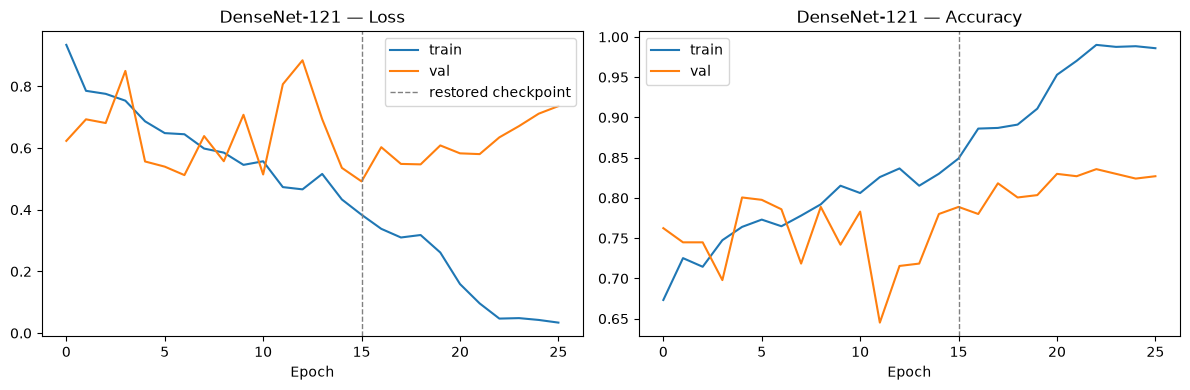

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.795


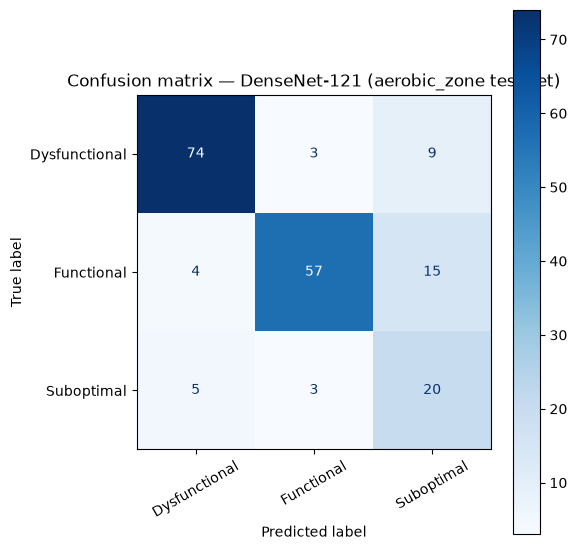

               precision    recall  f1-score   support

Dysfunctional      0.892     0.860     0.876        86
   Functional      0.905     0.750     0.820        76
   Suboptimal      0.455     0.714     0.556        28

     accuracy                          0.795       190
    macro avg      0.750     0.775     0.750       190
 weighted avg      0.832     0.795     0.806       190



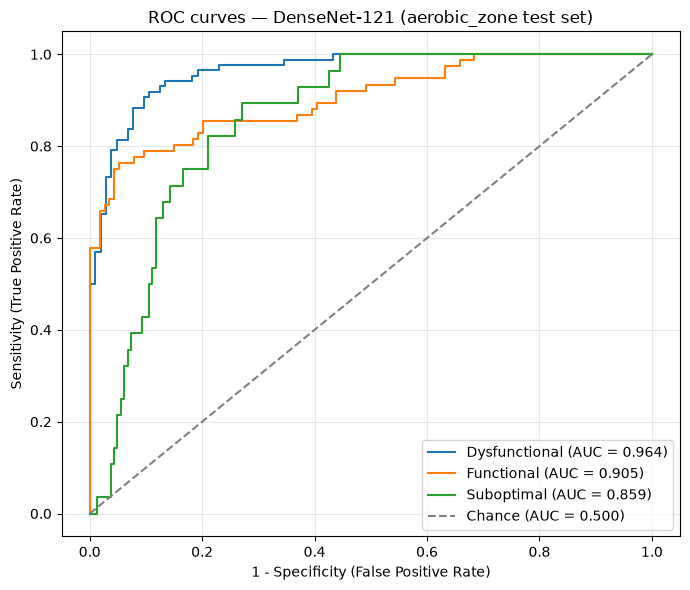

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.964
  Functional     : 0.905
  Suboptimal     : 0.859

Mean AUC (over 3/3 classes with test examples): 0.909


(np.float64(0.7947368421052632),
 {'Dysfunctional': 0.9643336314847942,
  'Functional': 0.9048938134810711,
  'Suboptimal': 0.8591269841269842})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/aerobic_zone_noaug/results_aerobic_zone_densenet121_stratified.pkl
Saved model weights to ../models/aerobic_zone_densenet121_cnn.pt
